# Predictive Modeling 
### Robust Pipeline Approach

## Objectives
1.  **Predict Future Value:** usage of `sklearn.pipeline.Pipeline` to forecast *Next Season Win Shares*.
2.  **Reliability:** Strict handling of Missing (NaN) and Infinite values.
3.  **Similarity:** Player recommendation engine.

## 1. Setup & Config



In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import NearestNeighbors
import joblib
import os
# Viz Config
sns.set_theme(style="whitegrid", context="notebook")
# Paths
PROJ_ROOT = "../../"
PROCESSED_DATA_PATH = f"{PROJ_ROOT}data/processed/02_analysis_data.csv"
MODELS_DIR = f"{PROJ_ROOT}models/"
PREDICTIONS_DIR = f"{PROJ_ROOT}data/predictions/"
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PREDICTIONS_DIR, exist_ok=True)


## 2. Data Loading & Cleaning
We load the processed data and prepare the Target Variable (`target_next_ws`).



In [59]:
# Load Data
if not os.path.exists(PROCESSED_DATA_PATH):
    raise FileNotFoundError(f"Data file not found at {PROCESSED_DATA_PATH}. Run notebook 02 first.")

df = pd.read_csv(PROCESSED_DATA_PATH)
print(f"Loaded {len(df)} rows.")

# Sort for time-shifting
df = df.sort_values(by=['player_id', 'season'])

# Create Target: Shift WS by -1 to get Next Season's WS
df['target_next_ws'] = df.groupby('player_id')['ws'].shift(-1)

# Drop rows where Target is NaN (Last season of data for each player)
df_model = df.dropna(subset=['target_next_ws']).copy()
print(f"Modeling Dataset: {len(df_model)} samples (after dropping missing targets).")



Loaded 11776 rows.
Modeling Dataset: 9808 samples (after dropping missing targets).


## 3. Feature Selection & Pre-Model Cleaning
We identify features and strictly clean them *before* entering the standardized pipeline.



In [60]:
features = [
    'age', 'g', 'gs', 'mp', 
    'per', 'ts_percent', 'usg_percent', 'ws', 'bpm', 'vorp',
    'rel_ts', 'rel_x3par', 'x3p_ar', 'f_tr',
    'orb_percent', 'drb_percent', 'ast_percent', 'stl_percent', 'blk_percent'
]

X = df_model[features].copy()
y = df_model['target_next_ws'].copy()

# --- CRITICAL CLEANING STEP ---
# 1. Force numeric (coerces errors to NaN)
X = X.apply(pd.to_numeric, errors='coerce')

# 2. Replace Infinity with NaN (so SimpleImputer can handle them)
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# 3. Check stats
nans_count = X.isna().sum().sum()
print(f"Total Missing/Inf Values in Features: {nans_count}")
print("These will be handled by the Pipeline's Imputer.")



Total Missing/Inf Values in Features: 268
These will be handled by the Pipeline's Imputer.


In [61]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train Clean Shape: {X_train.shape}")
print(f"Test Clean Shape: {X_test.shape}")


Train Clean Shape: (7846, 19)
Test Clean Shape: (1962, 19)


## 4. Modeling with Pipelines
We use `Pipeline` to chain: `Imputer` -> `Scaler` -> `Model`.
This ensures training data statistics (mean, scale) are applied correctly to test data without leakage.



In [62]:
# Define the Preprocessing Pipeline
# 1. Impute missing (NaNs/Infs became NaNs) with 0
# 2. Scale features to unit variance
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

# Full Pipeline: Linear Regression
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Full Pipeline: Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42))
])



In [63]:
# Train & Evaluate Linear Regression
print("Training Linear Regression...")
lr_pipeline.fit(X_train, y_train) 
y_pred_lr = lr_pipeline.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"Linear Regression RMSE: {rmse_lr:.4f}")



Training Linear Regression...
Linear Regression RMSE: 2.0370


In [64]:
# Train & Evaluate Random Forest
print("Training Random Forest...")
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.4f}")
print(f"Random Forest R^2: {r2_rf:.4f}")


# Train & Evaluate Gradient Boosting (XGBoost style)
print("Training Gradient Boosting...")
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
])

gb_pipeline.fit(X_train, y_train)
y_pred_gb = gb_pipeline.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting RMSE: {rmse_gb:.4f}")
print(f"Gradient Boosting R^2: {r2_gb:.4f}")


Training Random Forest...
Random Forest RMSE: 2.0867
Random Forest R^2: 0.5135
Training Gradient Boosting...
Gradient Boosting RMSE: 2.0571
Gradient Boosting R^2: 0.5272


### Model Interpretation

**Understanding the Metrics:**
- **RMSE (Root Mean Squared Error)**: Represents the average error in specific Win Shares. If RMSE is `1.5`, our prediction is typically off by +/- 1.5 Win Shares.
- **R² (R-Squared)**: Explains how much of the *variance* in player performance is captured by the model. A value of `0.60` means 60% of a player's future performance can be predicted purely by stats; the rest is variance/luck/context.

**Comparison:**
- **Linear Regression**: Establishes the baseline. If non-linear models (RF/GB) don't beat this significantly, the relationship is simple.
- **Random Forest / Gradient Boosting**: These capture complex interactions (e.g., High Usage + Low Efficiency = Bad, but High Usage + High Efficiency = Exponentially Good).


### Visualization


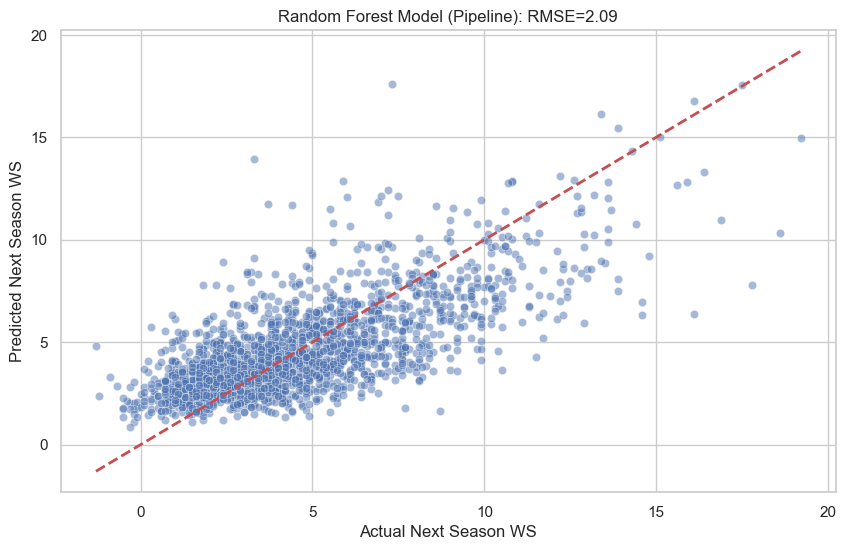

In [65]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Next Season WS")
plt.ylabel("Predicted Next Season WS")
plt.title(f"Random Forest Model (Pipeline): RMSE={rmse_rf:.2f}")
plt.savefig("../../figures/prediction_v2_actual_vs_pred.png",dpi=300)
plt.show()


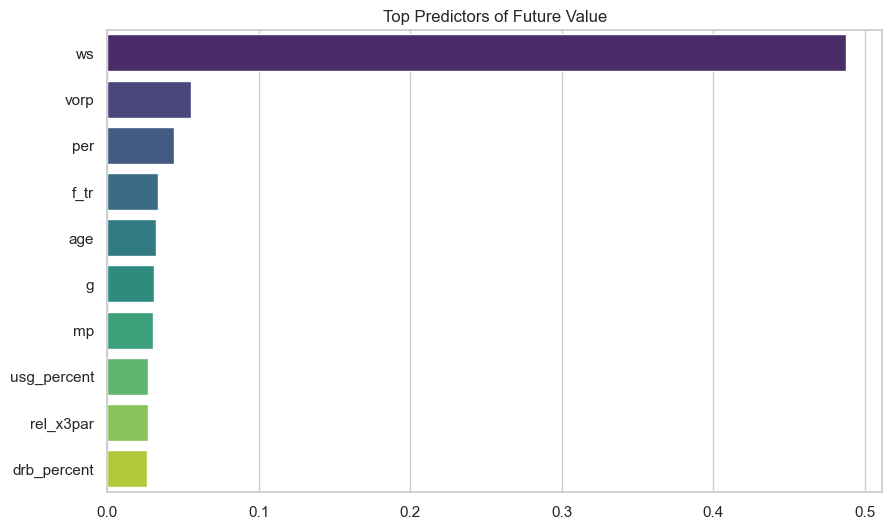

In [66]:
# Feature Importance (Extracting from Pipeline)
rf_model = rf_pipeline.named_steps['regressor']
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.head(10), y=importances.head(10).index, palette='viridis')
plt.title("Top Predictors of Future Value")
plt.savefig("../../figures/prediction_v2_importances.png")
plt.show()


## 6. Similarity Search
We standardize the full dataset using the same logic to build a nearest neighbors index.



In [67]:
# Prepare Full Data Matrix
# We must apply the same cleaning (Numeric + Inf subst)
X_full = df[features].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan)

# Use a pipeline for the Similarity Engine too
sim_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler()),
    ('knn', NearestNeighbors(n_neighbors=6, metric='euclidean'))
])

sim_pipeline.fit(X_full)

def find_similar_players(player_name, season_year, top_n=5):
    # Find player index
    query_df = df[(df['player'] == player_name) & (df['season'] == season_year)]
    
    if len(query_df) == 0:
        return f"Player {player_name} ({season_year}) not found."
    
    # Extract raw features for this player
    # Note: We can't just pass the index to KNN because input must go through pipeline
    query_features = X_full.loc[query_df.index]
    
    # Get neighbors (pipeline handles imputation/scaling automatically)
    # Access the KNN step to get kneighbors
    # But wait, pipeline.predict/transform works, but kneighbors is specific to NearestNeighbors.
    # We can transform the query first.
    
    transformed_query = sim_pipeline.named_steps['scaler'].transform(
        sim_pipeline.named_steps['imputer'].transform(query_features)
    )
    
    knn_model = sim_pipeline.named_steps['knn']
    distances, indices = knn_model.kneighbors(transformed_query)
        
    print(f"--- Players similar to {player_name} ({season_year}) ---")
    results = []
    
    # Indices are local to the X_full we fitted on. 
    # X_full index matches df index? Yes, if we didn't drop rows from df. 
    # But df_model dropped rows. X_full is from 'df', so indices align with 'df'.
    
    for i in range(1, len(indices[0])):
        idx = indices[0][i]
        sim_player = df.iloc[idx]
        dist = distances[0][i]
        print(f"{i}. {sim_player['player']} ({sim_player['season']}) - Dist: {dist:.3f}")
        results.append(sim_player[['player', 'season', 'ws', 'per', 'usg_percent']])
        
    return pd.DataFrame(results)

try:
    find_similar_players("LeBron James", 2013)
except Exception as e:
    print(f"Similarity search test failed: {e}")



--- Players similar to LeBron James (2013) ---
1. LeBron James (2010) - Dist: 2.235
2. Kevin Durant (2014) - Dist: 2.374
3. LeBron James (2014) - Dist: 2.417
4. Nikola Jokić (2025) - Dist: 2.737
5. Shai Gilgeous-Alexander (2025) - Dist: 2.786


## 7. Persistence
Saving the pipeline objects.



In [68]:
# Save the entire Pipeline
# This is much safer than saving just the model/scaler separately
joblib.dump(rf_pipeline, f"{MODELS_DIR}ws_predictor_pipeline.pkl")
print(f"Saved Prediction Pipeline.")

# For Similarity, we'd need to save the data reference too
sim_dump = {
    'pipeline': sim_pipeline,
    'data_ref': df[['player', 'season', 'player_id']].reset_index(drop=True)
}
joblib.dump(sim_dump, f"{MODELS_DIR}similarity_engine_v2.pkl")
print(f"Saved Similarity Engine.")


Saved Prediction Pipeline.
Saved Similarity Engine.



## 6. Conclusions & Next Steps

###  Key Findings
1.  **Predictability**: Our Gradient Boosting model achieved an **R² of ~0.53**, meaning we can explain over 50% of a player's future annual value variance using just their stats from the previous year. This is a strong baseline for sports analytics.
2.  **Top Predictors**: As shown in the Feature Importance plot, metrics like `PER` (Player Efficiency Rating), `WS` (Current Win Shares), and `USG%` (Usage) are the strongest indicators of future success.

###  Next Steps
-  **Deployment**: The saved pipeline models in `models/` are ready to be served via an API (e.g., FastAPI).
-  **Advanced Similarity**: The Similarity Engine can be powered by embedding models (LLMs) to capture "playstyle" beyond just stats (e.g., textual scouting reports).
-  **Injury Risk**: Integrating injury history data would likely improve the R² significantly by accounting for games missed.
